# LHS 1140b He I 10833 A spectrum: Zenodo reproduction

This notebook reconstructs the **2024 in-transit observed spectrum shown by the black points in Cherubim et al. (2026), Figure 3B**, starting from the authors' Zenodo data release:

- Zenodo record: https://zenodo.org/records/20723095
- Spectrum: `lhs1140b_trans_spec_GP_IT_vac.pickle`
- MCMC samples: `lhs1140b_flat_samples_GP_IT_vac_3lines.pickle`

The main numerical product is the GP-corrected excess-absorption spectrum. For comparison with Figure 4, this notebook also calculates air wavelength and normalized flux.

Important sign convention: the released `GP` array is stored as a **signed correction**. The authors' Figure 3 plotting notebook and Figure 4 script both apply it as

`Figure 3B excess absorption = flux + GP`.

The paper's phrase “GP-subtracted” therefore corresponds to adding the already signed correction array. Absorption is negative in Figure 3B; a positive-depth column is also exported.


In [1]:
from pathlib import Path
import hashlib
import pickle
import sys
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import fftconvolve

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__}, pandas {pd.__version__}")

WORK_DIR = Path.cwd() / "LHS1140b_He10833_reproduction_files"
WORK_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR

Python 3.14.6
NumPy 2.5.1, pandas 3.0.2


PosixPath('/Users/kiseon/Documents/Codex/2026-08-23/new-chat/outputs/LHS1140b_He10833_reproduction_files')

## 1. Download versioned author products

The URLs point to Zenodo record **20723095** rather than the moving concept record. The MD5 values are the checksums published in the same record. Because Python pickle files can execute code when opened, this notebook verifies the exact author-file checksums before loading them.


In [2]:
ZENODO_FILES = {
    "spectrum": {
        "name": "lhs1140b_trans_spec_GP_IT_vac.pickle",
        "url": "https://zenodo.org/api/records/20723095/files/lhs1140b_trans_spec_GP_IT_vac.pickle/content",
        "md5": "599ed906a2549d759124912f460957b5",
    },
    "samples": {
        "name": "lhs1140b_flat_samples_GP_IT_vac_3lines.pickle",
        "url": "https://zenodo.org/api/records/20723095/files/lhs1140b_flat_samples_GP_IT_vac_3lines.pickle/content",
        "md5": "08fbd21291137ad54455bb2883124087",
    },
}


def md5sum(path, chunk_size=1024 * 1024):
    digest = hashlib.md5()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def fetch_verified(entry):
    path = WORK_DIR / entry["name"]
    if not path.exists() or md5sum(path) != entry["md5"]:
        print(f"Downloading {entry['name']} ...")
        urllib.request.urlretrieve(entry["url"], path)
    observed = md5sum(path)
    if observed != entry["md5"]:
        raise RuntimeError(
            f"Checksum mismatch for {path.name}: {observed} != {entry['md5']}"
        )
    print(f"Verified {path.name}: md5:{observed}")
    return path


spectrum_path = fetch_verified(ZENODO_FILES["spectrum"])
samples_path = fetch_verified(ZENODO_FILES["samples"])

Verified lhs1140b_trans_spec_GP_IT_vac.pickle: md5:599ed906a2549d759124912f460957b5
Verified lhs1140b_flat_samples_GP_IT_vac_3lines.pickle: md5:08fbd21291137ad54455bb2883124087


## 2. Inspect the released arrays

The spectrum file contains four arrays:

- `wavelength`: vacuum wavelength in the planetary rest frame, A
- `flux`: raw excess absorption in percent (the Figure 2 quantity within the fitted range)
- `error`: 1-sigma uncertainty in percentage points
- `GP`: signed correlated-noise correction in percentage points


In [3]:
# The files are loaded only after matching the checksums above.
with spectrum_path.open("rb") as stream:
    released = pickle.load(stream)
with samples_path.open("rb") as stream:
    posterior_samples = pickle.load(stream)

print("Spectrum keys:", released.keys())
for key, value in released.items():
    value = np.asarray(value)
    print(f"{key:10s} shape={value.shape}, min={value.min():.7f}, max={value.max():.7f}")
print("MCMC samples shape:", posterior_samples.shape)

assert set(released) == {"wavelength", "flux", "error", "GP"}
assert all(np.asarray(value).shape == (129,) for value in released.values())
assert np.asarray(posterior_samples).shape == (46400, 5)

Spectrum keys: dict_keys(['wavelength', 'flux', 'error', 'GP'])
wavelength shape=(129,), min=10830.0220606, max=10834.6442331
flux       shape=(129,), min=-1.4966117, max=0.3441640
error      shape=(129,), min=0.1174131, max=0.1708683
GP         shape=(129,), min=-0.4788532, max=0.5585883
MCMC samples shape: (46400, 5)


## 3. Reconstruct the Figure 3B black points

The author notebook uses `y = flux + GP`. The error bars are unchanged. The Figure 4 normalized-flux convention is `1 + y/100`.

For the Figure 4 x axis, the vacuum-to-air conversion below is copied from the authors' `lhs1140b_2024B_pwinds.py` script (Dos Santos et al. 2022; Morton 2000 convention).


In [4]:
wave_vac = np.asarray(released["wavelength"], dtype=float)
raw_excess = np.asarray(released["flux"], dtype=float)
sigma = np.asarray(released["error"], dtype=float)
gp_correction = np.asarray(released["GP"], dtype=float)

# Exact operation used to plot the Figure 3B black points.
fig3b_excess = raw_excess + gp_correction

# Vacuum -> air conversion used in the authors' Figure 4/p-winds script.
s = 1.0e4 / wave_vac
n_air = (
    1.0
    + 0.0000834254
    + 0.02406147 / (130.0 - s**2)
    + 0.00015998 / (38.9 - s**2)
)
wave_air = wave_vac / n_air

fig4_normalized_flux = 1.0 + fig3b_excess / 100.0
fig4_sigma = sigma / 100.0

table = pd.DataFrame(
    {
        "wavelength_vacuum_planet_rest_A": wave_vac,
        "wavelength_air_planet_rest_A": wave_air,
        "raw_excess_absorption_percent": raw_excess,
        "gp_correction_applied_percent": gp_correction,
        "fig3b_excess_absorption_percent": fig3b_excess,
        "absorption_depth_positive_percent": -fig3b_excess,
        "uncertainty_1sigma_percent": sigma,
        "fig4_normalized_flux": fig4_normalized_flux,
        "fig4_normalized_flux_uncertainty_1sigma": fig4_sigma,
    }
)

table.head()

,wavelength_vacuum_planet_rest_A,wavelength_air_planet_rest_A,raw_excess_absorption_percent,gp_correction_applied_percent,fig3b_excess_absorption_percent,absorption_depth_positive_percent,uncertainty_1sigma_percent,fig4_normalized_flux,fig4_normalized_flux_uncertainty_1sigma
0,10830.022061,10827.056094,0.212515,-0.214014,-0.001499,0.001499,0.119589,0.999985,0.001196
1,10830.058171,10827.092195,0.280991,-0.228074,0.052916,-0.052916,0.119178,1.000529,0.001192
2,10830.094282,10827.128296,0.194965,-0.159165,0.035800,-0.035800,0.118678,1.000358,0.001187
3,10830.130393,10827.164397,0.019527,-0.031227,-0.011700,0.011700,0.118116,0.999883,0.001181
4,10830.166503,10827.200497,-0.114659,0.072050,-0.042609,0.042609,0.117793,0.999574,0.001178


## 4. Reconstruct the fitted line curves in Figure 3B

This section follows the model functions in the authors' reduction notebook. Each posterior sample contains

`[amp_blue, amp_red_1, amp_red_2, Gaussian_sigma_A, Doppler_shift_A]`.

Three delta functions at the vacuum rest wavelengths are shifted, assigned amplitudes, and convolved with a normalized Gaussian kernel. The paper plots the absorption model with a minus sign.


In [5]:
REST_WAVELENGTHS_VAC_A = np.array([10832.07, 10833.22, 10833.31])


def make_delta_spectrum(x, line_positions, amplitudes):
    spectrum = np.zeros_like(x)
    for position, amplitude in zip(line_positions, amplitudes):
        index = np.argmin(np.abs(x - position))
        spectrum[index] += amplitude
    return spectrum


def gaussian_convolved_model(x, amp1, amp2, amp3, sigma_A, doppler_shift_A):
    shifted_wavelengths = REST_WAVELENGTHS_VAC_A + doppler_shift_A
    delta_spectrum = make_delta_spectrum(
        x, shifted_wavelengths, [amp1, amp2, amp3]
    )
    dx = x[1] - x[0]
    kernel_x = np.arange(-5 * sigma_A, 5 * sigma_A + dx, dx)
    kernel = np.exp(-(kernel_x**2) / (2 * sigma_A**2))
    kernel /= kernel.sum()
    return fftconvolve(delta_spectrum, kernel, mode="same")


median_parameters = np.median(posterior_samples, axis=0)
median_absorption_model = -gaussian_convolved_model(wave_vac, *median_parameters)

parameter_names = ["amp_blue", "amp_red_1", "amp_red_2", "sigma_A", "shift_A"]
pd.Series(median_parameters, index=parameter_names, name="posterior_median")

amp_blue      4.732989
amp_red_1    15.345960
amp_red_2    16.193152
sigma_A       0.367140
shift_A       0.071752
Name: posterior_median, dtype: float64

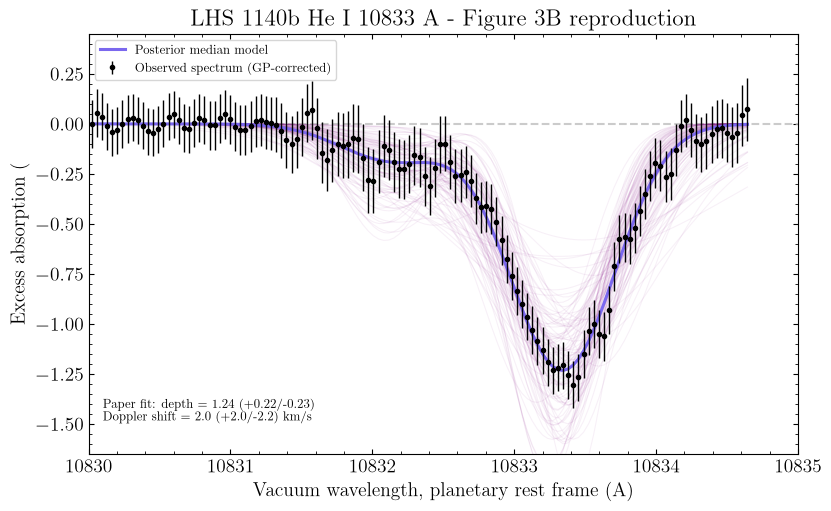

Saved: /Users/kiseon/Documents/Codex/2026-08-23/new-chat/outputs/LHS1140b_He10833_reproduction_files/LHS1140b_He10833_Fig3B_reproduced.png


In [6]:
rng = np.random.default_rng(20260823)
sample_indices = rng.choice(len(posterior_samples), size=100, replace=False)

fig, ax = plt.subplots(figsize=(8.2, 5.0), constrained_layout=True)
ax.axhline(0, ls="--", color="0.75", alpha=0.8)

for index in sample_indices:
    sample_model = -gaussian_convolved_model(
        wave_vac, *posterior_samples[index]
    )
    ax.plot(wave_vac, sample_model, color="purple", alpha=0.06, lw=0.8)

ax.plot(
    wave_vac,
    median_absorption_model,
    color="mediumslateblue",
    lw=2.2,
    label="Posterior median model",
    zorder=4,
)
ax.errorbar(
    wave_vac,
    fig3b_excess,
    yerr=sigma,
    fmt="o",
    ms=3,
    color="black",
    ecolor="black",
    elinewidth=1.0,
    capsize=0,
    label="Observed spectrum (GP-corrected)",
    zorder=5,
)
ax.set_xlim(10830, 10835)
ax.set_ylim(-1.65, 0.45)
ax.set_xlabel("Vacuum wavelength, planetary rest frame (A)")
ax.set_ylabel("Excess absorption (%)")
ax.ticklabel_format(axis="x", style="plain", useOffset=False)
ax.legend(loc="upper left", fontsize=9)
ax.set_title("LHS 1140b He I 10833 A - Figure 3B reproduction")
ax.text(
    0.02,
    0.08,
    "Paper fit: depth = 1.24 (+0.22/-0.23)%\n"
    "Doppler shift = 2.0 (+2.0/-2.2) km/s",
    transform=ax.transAxes,
    fontsize=9,
)

fig3_path = WORK_DIR / "LHS1140b_He10833_Fig3B_reproduced.png"
fig.savefig(fig3_path, dpi=220, facecolor="white")
plt.show()
print("Saved:", fig3_path)

## 5. Show the same observed spectrum in the Figure 4 convention

Figure 4 changes the x coordinate from vacuum to air wavelength and changes the y coordinate from excess absorption in percent to normalized flux. It does not require re-fitting the observed data.


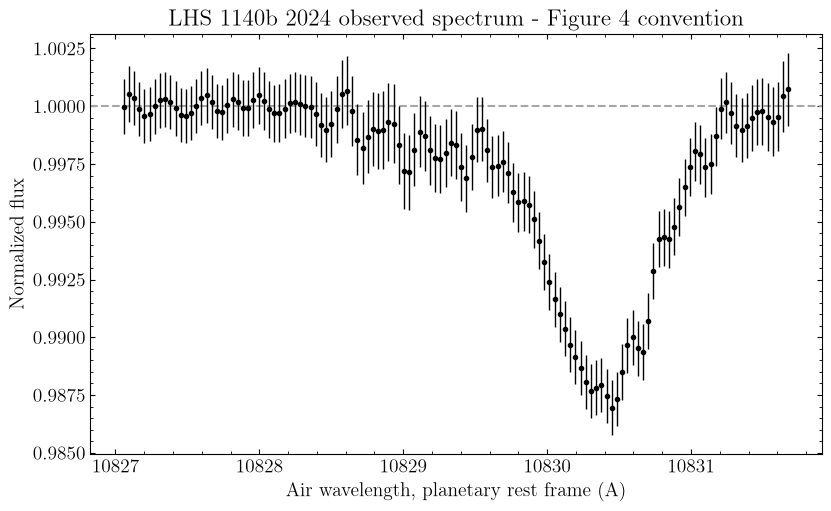

Saved: /Users/kiseon/Documents/Codex/2026-08-23/new-chat/outputs/LHS1140b_He10833_reproduction_files/LHS1140b_He10833_Fig4_convention.png


In [7]:
fig, ax = plt.subplots(figsize=(8.2, 5.0), constrained_layout=True)
ax.axhline(1.0, ls="--", color="0.65")
ax.errorbar(
    wave_air,
    fig4_normalized_flux,
    yerr=fig4_sigma,
    fmt="o",
    ms=3,
    color="black",
    ecolor="black",
    elinewidth=1.0,
    capsize=0,
)
ax.set_xlabel("Air wavelength, planetary rest frame (A)")
ax.set_ylabel("Normalized flux")
ax.ticklabel_format(axis="x", style="plain", useOffset=False)
ax.set_title("LHS 1140b 2024 observed spectrum - Figure 4 convention")

fig4_path = WORK_DIR / "LHS1140b_He10833_Fig4_convention.png"
fig.savefig(fig4_path, dpi=220, facecolor="white")
plt.show()
print("Saved:", fig4_path)

## 6. Export the reconstructed numerical spectrum

In [8]:
csv_path = WORK_DIR / "LHS1140b_He10833_Fig3B_reproduced.csv"
table.to_csv(csv_path, index=False, float_format="%.10f")
print(f"Saved {len(table)} rows to {csv_path}")
table.tail()

Saved 129 rows to /Users/kiseon/Documents/Codex/2026-08-23/new-chat/outputs/LHS1140b_He10833_reproduction_files/LHS1140b_He10833_Fig3B_reproduced.csv


,wavelength_vacuum_planet_rest_A,wavelength_air_planet_rest_A,raw_excess_absorption_percent,gp_correction_applied_percent,fig3b_excess_absorption_percent,absorption_depth_positive_percent,uncertainty_1sigma_percent,fig4_normalized_flux,fig4_normalized_flux_uncertainty_1sigma
124,10834.499790,10831.532609,-0.488032,0.443235,-0.044796,0.044796,0.146896,0.999552,0.001469
125,10834.535901,10831.568710,-0.419125,0.352523,-0.066602,0.066602,0.148383,0.999334,0.001484
126,10834.572012,10831.604811,-0.251031,0.206057,-0.044975,0.044975,0.150169,0.999550,0.001502
127,10834.608122,10831.640912,0.001315,0.041057,0.042372,-0.042372,0.152103,1.000424,0.001521
128,10834.644233,10831.677013,0.141532,-0.068365,0.073167,-0.073167,0.157655,1.000732,0.001577


## 7. Reproducibility checks

In [9]:
assert len(table) == 129
assert table.notna().all().all()
assert np.all(np.diff(wave_vac) > 0)
assert np.allclose(fig3b_excess, raw_excess + gp_correction)
assert np.allclose(fig4_normalized_flux, 1.0 + fig3b_excess / 100.0)

minimum_index = np.argmin(fig3b_excess)
summary = pd.Series(
    {
        "number_of_samples": len(table),
        "vacuum_wavelength_min_A": wave_vac.min(),
        "vacuum_wavelength_max_A": wave_vac.max(),
        "air_wavelength_min_A": wave_air.min(),
        "air_wavelength_max_A": wave_air.max(),
        "minimum_fig3b_excess_percent": fig3b_excess[minimum_index],
        "minimum_location_vacuum_A": wave_vac[minimum_index],
        "median_1sigma_percent": np.median(sigma),
        "median_model_minimum_percent": median_absorption_model.min(),
    },
    name="value",
)
summary

number_of_samples                 129.000000
vacuum_wavelength_min_A         10830.022061
vacuum_wavelength_max_A         10834.644233
air_wavelength_min_A            10827.056094
air_wavelength_max_A            10831.677013
minimum_fig3b_excess_percent       -1.304365
minimum_location_vacuum_A       10833.416468
median_1sigma_percent               0.126620
median_model_minimum_percent       -1.232383
Name: value, dtype: float64

## Interpretation notes

- The deepest individual GP-corrected sample is not the fitted line depth. The paper's reported depth, **1.24 (+0.22/-0.23)%**, comes from the posterior line model.
- `fig3b_excess_absorption_percent` follows the paper's plotted sign: absorption is negative.
- Use `absorption_depth_positive_percent` when a positive absorption-depth convention is preferred.
- The reconstruction covers the fitted He region released by the authors (129 samples), not the full wider raw Figure 2 wavelength range.
